<a href="https://colab.research.google.com/github/jainharshita794-jpg/customer-shopping-trends-analysis/blob/main/customer_shopping_trends_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Customer Shopping Trends Analysis
---
### Data Analysis Project

**Tools used:** Python , Pandas , Matplotlib , Seaborn
---

---
## 1. INTRODUCTION

This project analyzes customer shopping behavior using Python data analysis techniques.

Analyzing customer shopping behavior is useful because it helps businesses understand what customer buy , how much they spend ,their preferences and purchasing pattern.
These insights help businesses improve marketing strategics, products selection, customer satisfaction and sales.

## 2. Objective
The objective of this project is to analyze customer shopping behavior and identify patterns in customer purchases.

This includes:
- Understanding customer demographics and purchasing habits.
- Identifying popular product categories and shopping seasons.
- Analyzing spending patterns across different customer groups.
- Exploring payment preferences and other factors that influence shopping trends.

---
## 2.1. Importing Required Libraries

The following Python libraries are used for data manipulation,
analysis, and visualization.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## 2.2. Loading Dataset
The dataset is loaded using Pandas and stored in a DataFrame.

In [ ]:
df = pd.read_excel("/content/shopping_trends_dataset.xlsx.xlsx")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Season,Review Rating,Payment Method,Frequency of Purchases,Subscription Status
0,890.0,59.0,Male,Belt,Accessories,84,Arizona,Fall,2.8,Venmo,Weekly,Yes
1,3770.0,51.0,Female,Gloves,Accessories,87,Arizona,Summer,3.6,Venmo,Annually,No
2,1236.0,23.0,Male,Sweater,Clothing,22,Idaho,Spring,3.0,PayPal,Every 3 Months,No
3,2217.0,41.0,Male,Pants,Clothing,36,Vermont,Winter,4.0,Venmo,Bi-Weekly,No
4,1432.0,39.0,Male,Pants,Clothing,88,South Dakota,Fall,2.9,Venmo,Quarterly,No


---
## 3 Dataset Description

This original dataset contains **410 rows** and **12 columns**. Each row represents a customer's shopping record, while each column contains information such as Customer ID, Age, Gender, Item Purchased, Category, Purchase Amount (USD), Location, Season, Review Rating,Payment Method, Subscription Status




In [ ]:
df.shape

(410, 12)

In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Season', 'Review Rating',
       'Payment Method', 'Frequency of Purchases', 'Subscription Status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             408 non-null    float64
 1   Age                     409 non-null    float64
 2   Gender                  407 non-null    object 
 3   Item Purchased          407 non-null    object 
 4   Category                406 non-null    object 
 5   Purchase Amount (USD)   410 non-null    int64  
 6   Location                407 non-null    object 
 7   Season                  409 non-null    object 
 8   Review Rating           410 non-null    float64
 9   Payment Method          410 non-null    object 
 10  Frequency of Purchases  409 non-null    object 
 11  Subscription Status     408 non-null    object 
dtypes: float64(3), int64(1), object(8)
memory usage: 38.6+ KB


##4.Data Preprocessing & Cleaning

Data preprocessing and cleaning is the process of preparing raw data for analysis. It improves data quality, consistency, and model performance.

4.1 Checking for missing value



In [ ]:
df.isnull().sum()

,0
Customer ID,2
Age,1
Gender,3
Item Purchased,3
Category,4
Purchase Amount (USD),0
Location,3
Season,1
Review Rating,0
Payment Method,0


Missing Value Handling

Numeric columns: Fill with median.

Categorical columns: Fill with mode.

Customer ID: Drop rows with missing IDs.


In [ ]:
num_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating']

cat_cols = ['Gender', 'Item Purchased', 'Category', 'Location', 'Season',
            'Payment Method', 'Frequency of Purchases', 'Subscription Status']

# Fill numeric columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove rows with missing Customer ID
df.dropna(subset=['Customer ID'], inplace=True)

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


4.2 checking and removing duplicate rows

In [ ]:
print("Duplicate rows found :",df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found : 10
Shape after removing duplicates: (398, 12)


### 4.3 Detecting and handling outliers

Looking at the summary statistics for `Age`, the maximum value comes out to **350**, which is clearly an invalid data-entry error (no customer can be 350 years old). so removing rows with unrealistic ages (kept between 15 and 100).

I also check `Purchase Amount (USD)` for outliers using the IQR method.

In [ ]:
df['Age'].describe()

,Age
count,398.000000
mean,46.613065
std,30.535787
min,18.000000
25%,32.000000
50%,45.000000
75%,57.750000
max,350.000000


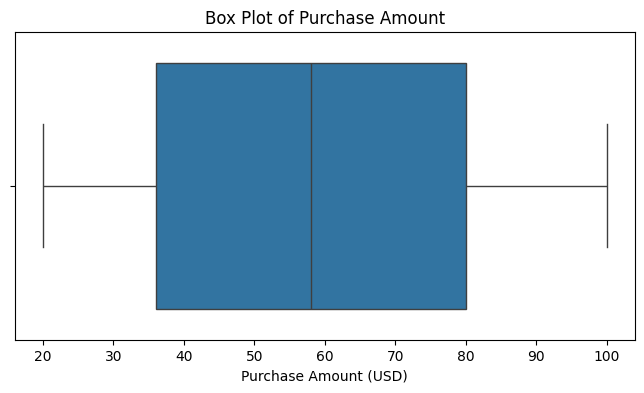

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Purchase Amount (USD)"])
plt.title("Box Plot of Purchase Amount")
plt.show()

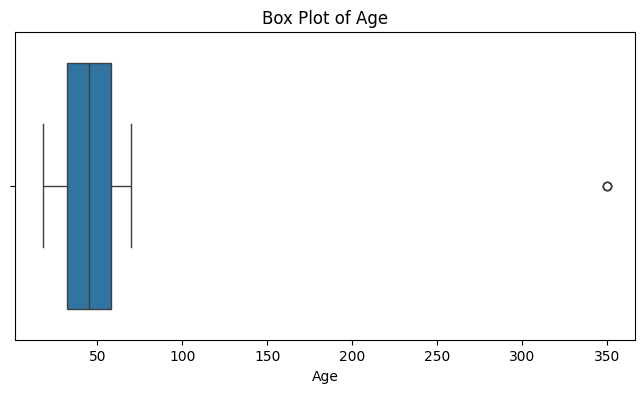

Final dataset shape: (395, 12)


In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")
plt.show()



In [ ]:
# Remove invalid Age values
before = len(df)
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)].reset_index(drop=True)

after = len(df)

print("Invalid Age rows removed:", before - after)
print("Rows remaining:", after)



Invalid Age rows removed: 4
Rows remaining: 406


In [ ]:
# Find IQR for Purchase Amount
Q1 = df['Purchase Amount (USD)'].quantile(0.25)
Q3 = df['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1

# Set outlier limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove Purchase Amount outliers
df = df[
    (df['Purchase Amount (USD)'] >= lower) &
    (df['Purchase Amount (USD)'] <= upper)
]

print("Final dataset shape:", df.shape)

## 5 Data Exploration
5.1 Descriptive Statistics

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating
count,395.000000,395.000000,395.000000,395.000000
mean,2006.843038,44.308861,58.351899,3.723544
std,1910.274402,15.276497,23.847021,0.736522
min,9.000000,18.000000,20.000000,2.500000
25%,912.000000,31.500000,36.000000,3.100000
50%,1878.000000,45.000000,58.000000,3.700000
75%,2842.500000,57.000000,79.500000,4.400000
max,19500.000000,70.000000,100.000000,5.000000


In [ ]:
df.describe(include='object')

,Gender,Item Purchased,Category,Location,Season,Payment Method,Frequency of Purchases,Subscription Status
count,395,395,395,395,395,395,395,395
unique,2,25,4,50,4,6,7,2
top,Male,Socks,Clothing,Vermont,Fall,Venmo,Annually,No
freq,284,25,179,17,120,74,66,287


### 5.2 Correlation analysis

In [ ]:
corr = df[['Age', 'Purchase Amount (USD)', 'Review Rating']].corr()
corr

,Age,Purchase Amount (USD),Review Rating
Age,1.000000,-0.018142,0.023015
Purchase Amount (USD),-0.018142,1.000000,0.048688
Review Rating,0.023015,0.048688,1.000000


The correlation results are close to zero, indicating very weak relationships among Age, Purchase Amount, and Review Rating.

## 6. Data Visualization

##6.1.Bar Chart — Average Purchase Amount by Category

Why: Shows which product categories generate higher average spending

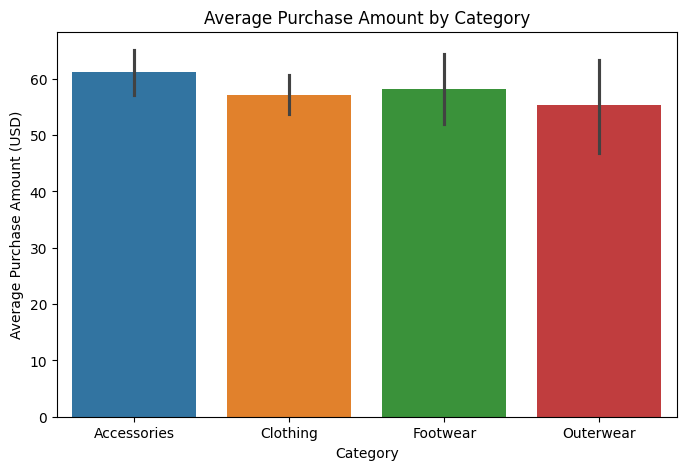

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Purchase Amount (USD)',
    data=df,
    estimator='mean',
    hue='Category',
    legend=False
)

plt.title('Average Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

**Insight** :  Accessories have the highest average purchase amount, while Outerwear has the lowest. This shows that spending varies slightly across product categories.

##6.2 Bar chart-Average Purchase Amount by Subscription Status

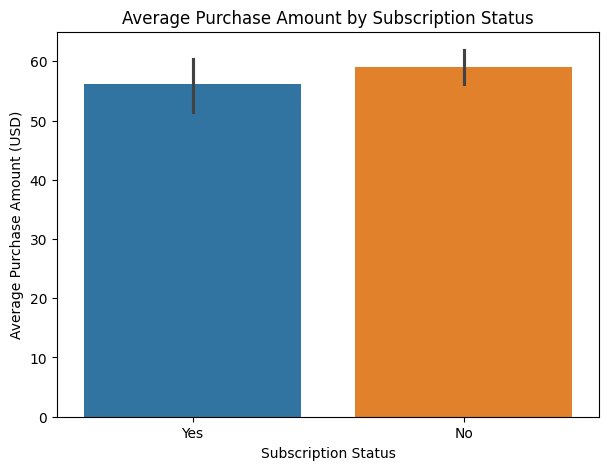

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Subscription Status',
    y='Purchase Amount (USD)',
    data=df,
    estimator='mean',
    hue='Subscription Status',
    legend=False
)
plt.title('Average Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

 **Insight** : The chart compares average spending between subscribed and non-subscribed customers. Since most customers in the dataset are not subscribed, subscription-based offers could be explored to improve customer loyalty.

##6.3 Correlation Heatmap

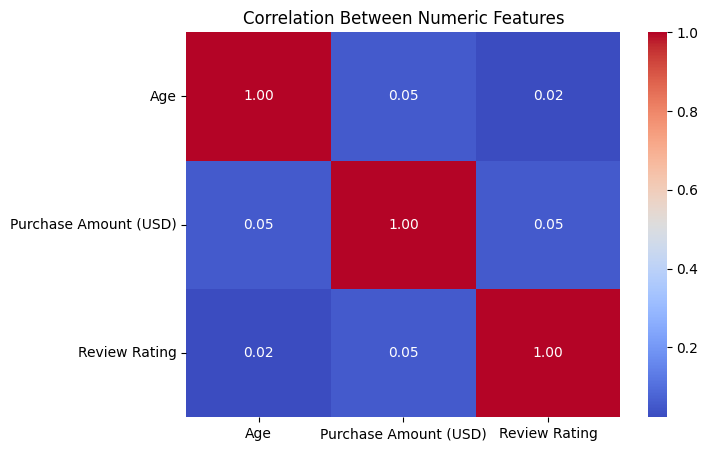

In [ ]:
plt.figure(figsize=(7,5))

corr = df[['Age', 'Purchase Amount (USD)', 'Review Rating']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Numeric Features')
plt.show()

**Insight** : Age, Purchase Amount, and Review Rating show very weak correlations. This suggests that age does not strongly influence spending or review ratings in this dataset.

##6.4  Histogram Age Distribution

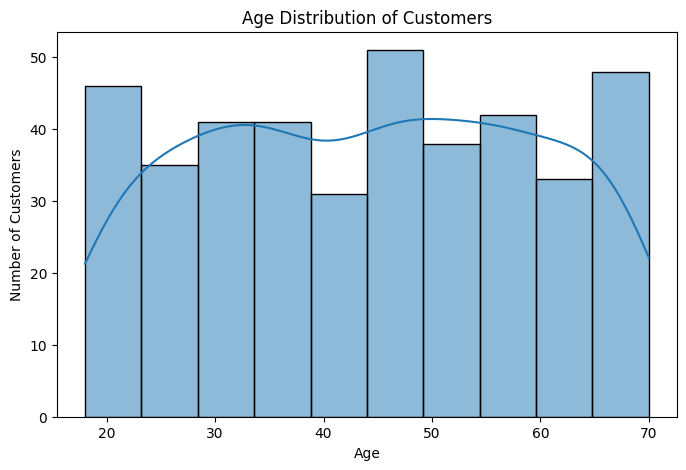

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=10,
    kde=True
)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

**Insight**: The histogram shows how customers are distributed across different age groups. It helps identify the most common customer age range.

##6.5 Count Plot — Purchases by Payment Method

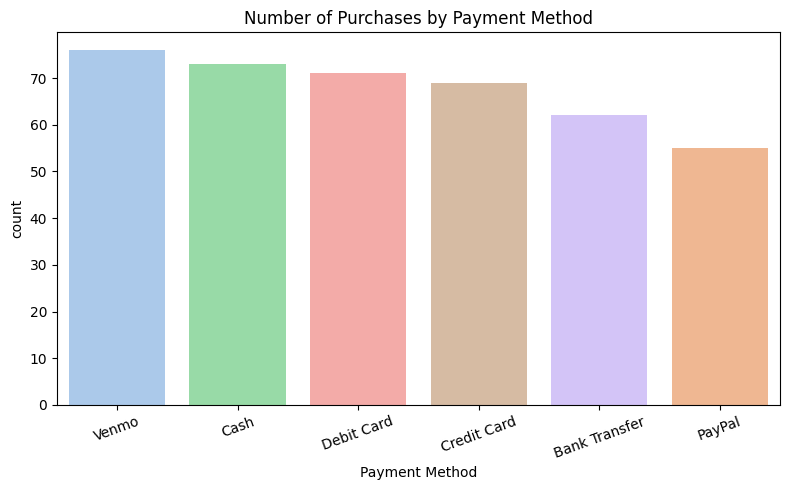

In [ ]:
plt.figure(figsize=(8, 5))
order = df['Payment Method'].value_counts().index
sns.countplot(x='Payment Method', data=df, order=order, hue='Payment Method', palette='pastel', legend=False)
plt.title('Number of Purchases by Payment Method')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Insight**: Venmo is the most preferred payment method, showing a strong customer preference for digital payments.

##6.6 countplot Season Analysis

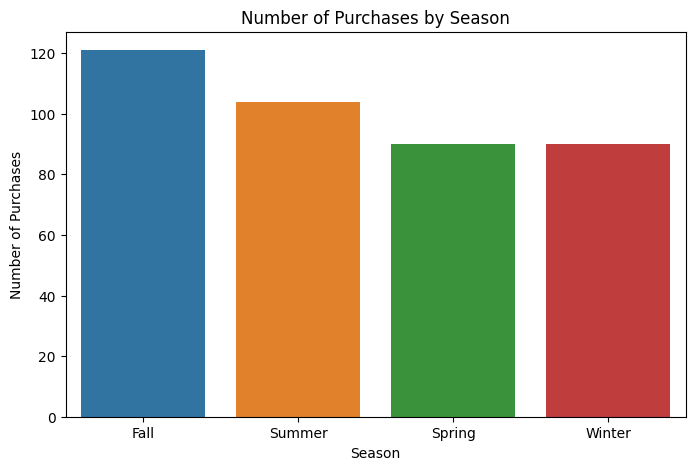

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Season',
    order=df['Season'].value_counts().index,
    hue='Season',
    legend=False
)

plt.title('Number of Purchases by Season')
plt.xlabel('Season')
plt.ylabel('Number of Purchases')
plt.show()

### **Key findings**

*   Average Spending: The average purchase amount is approximately $58.35, showing moderate customer spending.
*   Product Category: Accessories have the highest average purchase amount, while Outerwear has the lowest.
*   Customer Rating: The average review rating is approximately 3.72/5, indicating moderate customer satisfaction.
*   Payment Preference: Venmo is the most commonly used payment method, showing a preference for digital payments.
*    Subscription: Most customers are not subscribed, indicating an opportunity to increase subscriptions through targeted offers.
*   Correlation: Age, purchase amount, and review rating have very weak correlations, suggesting that age does not strongly affect spending or ratings.









#  Key Insights & Conclusion

##  Key Insights

- **Clothing** is the most represented product category, while **Socks** are the most frequently purchased item.
- The average **purchase amount is $58.35**, with spending ranging from **$20 to $100**.
- The average **review rating is 3.72/5**, indicating moderate customer satisfaction.
- **Fall** is the most represented season, and **Venmo** is the most common payment method.
- Most customers have **no subscription**, while **annual purchasing** is the most common purchase frequency.
- Correlation analysis shows **very weak relationships** between Age, Purchase Amount, and Review Rating.

##  Recommendations

- Focus on popular products and categories.
- Use seasonal trends for better marketing and inventory planning.
- Encourage subscriptions through loyalty benefits and discounts.
- Improve customer experience to increase review ratings.
- Use multiple customer characteristics rather than age alone to understand spending behaviour.

##  Conclusion

The analysis provides useful insights into **customer shopping behaviour, product preferences, spending, and purchasing patterns**. Overall, the findings show that customer behaviour is influenced by multiple factors, while **age, spending, and review ratings have very weak relationships**. This analysis demonstrates how data visualization and statistical analysis can support better **business and marketing decisions**.